# Calibración de redes neuronales

## Preparando datos...
###Fashion dataset

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

### CIFAR10

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>airplane</td>
  </tr>
  <tr>
    <td>1</td>
    <td>automobile</td>
  </tr>
    <tr>
    <td>2</td>
    <td>bird</td>
  </tr>
    <tr>
    <td>3</td>
    <td>cat</td>
  </tr>
    <tr>
    <td>4</td>
    <td>deer</td>
  </tr>
    <tr>
    <td>5</td>
    <td>dog</td>
  </tr>
    <tr>
    <td>6</td>
    <td>frog</td>
  </tr>
    <tr>
    <td>7</td>
    <td>horse</td>
  </tr>
    <tr>
    <td>8</td>
    <td>ship</td>
  </tr>
    <tr>
    <td>9</td>
    <td>truck</td>
  </tr>
</table>

### Funciones auxiliares para tratar con los datos

In [2]:
# Instalación de dependencias
!pip install -q scikeras tensorflow

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator


# =========================
# Funciones para desequilibrio
# =========================

def reduceClass(idx_class, rate, train_images, train_labels):
    """
    Reduce un porcentaje de los datos de una clase específica en los conjuntos
    train_images y train_labels.

    Parámetros:
    - idx_class: índice de la clase que se desea reducir.
    - rate: porcentaje de reducción deseado, expresado como un número entre 0 y 1.
    - train_images: conjunto de imágenes de entrenamiento.
    - train_labels: conjunto de etiquetas de entrenamiento.

    Devuelve:
    - train_images_reduced: conjunto de imágenes de entrenamiento reducido.
    - train_labels_reduced: conjunto de etiquetas de entrenamiento reducido.
    """
    # Encontrar los índices de las muestras pertenecientes a la clase indicada
    idx_class_samples = np.where(train_labels == idx_class)[0]

    # Determinar cuántas muestras se van a eliminar
    num_samples_to_reduce = int(len(idx_class_samples) * rate)

    # Seleccionar aleatoriamente las muestras que se van a eliminar
    samples_to_reduce = np.random.choice(
        idx_class_samples,
        size=num_samples_to_reduce,
        replace=False
    )

    # Eliminar las muestras seleccionadas
    train_images_reduced = np.delete(train_images, samples_to_reduce, axis=0)
    train_labels_reduced = np.delete(train_labels, samples_to_reduce, axis=0)

    return train_images_reduced, train_labels_reduced


def aplicarDesequilibrio(train_images, train_labels, reduction_dict):
    """
    Aplica una reducción específica a las clases indicadas en un diccionario.

    Parámetros:
    - train_images: conjunto de imágenes de entrenamiento.
    - train_labels: conjunto de etiquetas de entrenamiento.
    - reduction_dict: diccionario en el que la clave es el índice de la clase
      y el valor es el porcentaje de reducción que se desea aplicar a esa clase.
      Cada valor debe estar entre 0 y 1.

      Ejemplo:
      {
          0: 0.999, 1: 0.999, 2: 0.999, 3: 0.999, 4: 0.999,
          5: 0.999, 6: 0.70, 7: 0.70, 8: 0.70, 9: 0.50
      }

    Devuelve:
    - train_images_out: conjunto de imágenes tras aplicar el desequilibrio.
    - train_labels_out: conjunto de etiquetas tras aplicar el desequilibrio.
    """
    # Crear copias para no modificar directamente los datos de entrada
    train_images_out = train_images.copy()
    train_labels_out = train_labels.copy()

    # Recorrer las clases indicadas en el diccionario
    for idx_class, rate in reduction_dict.items():

        # Comprobar que la tasa de reducción está en el rango válido
        if rate < 0 or rate > 1:
            raise ValueError(
                "Todos los valores de reduction_dict deben estar entre 0 y 1."
            )

        # Aplicar la reducción si la tasa es mayor que 0
        if rate > 0:
            train_images_out, train_labels_out = reduceClass(
                idx_class,
                rate,
                train_images_out,
                train_labels_out
            )

    return train_images_out, train_labels_out


def mostrarDistribucionClases(train_labels, val_labels, test_labels):
    """
    Muestra por consola el número y el porcentaje de muestras de cada clase
    en los conjuntos de entrenamiento, validación y test.

    Parámetros:
    - train_labels: conjunto de etiquetas de entrenamiento.
    - val_labels: conjunto de etiquetas de validación.
    - test_labels: conjunto de etiquetas de test.

    Devuelve:
    - No devuelve ningún valor. Muestra la información por consola.
    """
    # Obtener todas las clases presentes en alguno de los tres conjuntos
    clases = sorted(set(train_labels) | set(val_labels) | set(test_labels))

    total_train = len(train_labels)
    total_val = len(val_labels)
    total_test = len(test_labels)

    print("Distribución de clases:")
    print("Clase | Train              | Val                | Test")
    print("---------------------------------------------------------------")

    for clase in clases:
        num_train = np.sum(train_labels == clase)
        num_val = np.sum(val_labels == clase)
        num_test = np.sum(test_labels == clase)

        pct_train = 100 * num_train / total_train
        pct_val = 100 * num_val / total_val
        pct_test = 100 * num_test / total_test

        print(
            f"{clase:5d} | "
            f"{num_train:5d} ({pct_train:6.2f}%) | "
            f"{num_val:5d} ({pct_val:6.2f}%) | "
            f"{num_test:5d} ({pct_test:6.2f}%)"
        )


# =========================
# Funciones de visualización
# =========================

def muestraImagenes(images, labels, class_names, numImagenes=25):
    """
    Muestra por pantalla un conjunto de imágenes con sus etiquetas.

    Parámetros:
    - images: conjunto de imágenes.
    - labels: etiquetas asociadas a las imágenes.
    - class_names: nombres de las clases.
    - numImagenes: número de imágenes que se desea mostrar.

    Devuelve:
    - No devuelve ningún valor. Muestra las imágenes por pantalla.
    """
    plt.figure(figsize=(10, 10))

    for i in range(numImagenes):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)

        # Mostrar en escala de grises o en RGB según corresponda
        if images[i].ndim == 2:
            plt.imshow(images[i], cmap=plt.cm.binary)
        else:
            plt.imshow(images[i])

        plt.xlabel(class_names[labels[i]])

    plt.show()


# =========================
# Funciones para aumento de datos
# =========================

def creaGeneradorAumentados(
    rotation=0,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
):
    """
    Crea un generador de datos con técnicas de aumento.

    Parámetros:
    - rotation: rango de rotación aleatoria en grados.
    - width_shift_range: rango de desplazamiento horizontal aleatorio.
    - height_shift_range: rango de desplazamiento vertical aleatorio.
    - shear_range: rango de cizallamiento aleatorio.
    - zoom_range: rango de zoom aleatorio.
    - horizontal_flip: indica si se permite volteo horizontal aleatorio.

    Devuelve:
    - datagen: generador de imágenes aumentadas.
    """
    datagen = ImageDataGenerator(
        rotation_range=rotation,
        width_shift_range=width_shift_range,
        height_shift_range=height_shift_range,
        shear_range=shear_range,
        zoom_range=zoom_range,
        horizontal_flip=horizontal_flip,
        fill_mode="nearest"
    )

    return datagen


def _aseguraCanal(images):
    """
    Añade una dimensión de canal si las imágenes están en escala de grises
    y no la tienen explícitamente.

    Parámetros:
    - images: conjunto de imágenes.

    Devuelve:
    - images_out: conjunto de imágenes con formato compatible para Keras.
    """
    if images.ndim == 3:
        return np.expand_dims(images, axis=-1)
    return images


def generar_batches_aumentados(datagen, images, labels, batch_size=32):
    """
    Genera batches de imágenes aumentadas utilizando un generador de datos.

    Parámetros:
    - datagen: generador de datos para el aumento de imágenes.
    - images: conjunto de imágenes.
    - labels: etiquetas correspondientes a las imágenes.
    - batch_size: tamaño del batch.

    Devuelve:
    - Un generador que produce batches de imágenes aumentadas y etiquetas.
    """
    images_ready = _aseguraCanal(images)
    data_generator = datagen.flow(images_ready, labels, batch_size=batch_size)

    for images_batch, labels_batch in data_generator:
        yield images_batch, labels_batch


def entrenaConGeneradorAumentados(
    model,
    train_images,
    train_labels,
    val_images,
    val_labels,
    epochs,
    batch_size,
    datagen=None
):
    """
    Entrena un modelo utilizando técnicas de aumento de datos.

    Parámetros:
    - model: modelo que se desea entrenar.
    - train_images: conjunto de imágenes de entrenamiento.
    - train_labels: etiquetas de entrenamiento.
    - val_images: conjunto de imágenes de validación.
    - val_labels: etiquetas de validación.
    - epochs: número de épocas de entrenamiento.
    - batch_size: tamaño del batch.
    - datagen: generador de aumentados. Si es None, se crea uno por defecto.

    Devuelve:
    - history: historial del entrenamiento devuelto por Keras.
    """
    if datagen is None:
        datagen = creaGeneradorAumentados()

    train_images_ready = _aseguraCanal(train_images)
    val_images_ready = _aseguraCanal(val_images)

    data_generator = datagen.flow(
        train_images_ready,
        train_labels,
        batch_size=batch_size
    )

    history = model.fit(
        data_generator,
        steps_per_epoch=len(train_images) // batch_size,
        epochs=epochs,
        validation_data=(val_images_ready, val_labels)
    )

    return history

### Carga los datos en memoria

Versión de TensorFlow: 2.20.0
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 289s 2us/step
Total train: (5621, 32, 32) | (5621,)
Total val:   (10000, 32, 32) | (10000,)
Total test:  (10000, 32, 32) | (10000,)
Distribución de clases:
Clase | Train              | Val                | Test
---------------------------------------------------------------
    0 |     4 (  0.07%) |  1005 ( 10.05%) |  1000 ( 10.00%)
    1 |     5 (  0.09%) |   974 (  9.74%) |  1000 ( 10.00%)
    2 |     4 (  0.07%) |  1032 ( 10.32%) |  1000 ( 10.00%)
    3 |     4 (  0.07%) |  1016 ( 10.16%) |  1000 ( 10.00%)
    4 |     5 (  0.09%) |   999 (  9.99%) |  1000 ( 10.00%)
    5 |     5 (  0.09%) |   937 (  9.37%) |  1000 ( 10.00%)
    6 |  1191 ( 21.19%) |  1030 ( 10.30%) |  1000 ( 10.00%)
    7 |  1200 ( 21.35%) |  1001 ( 10.01%) |  1000 ( 10.00%)
    8 |  1193 ( 21.22%) |  1025 ( 10.25%) |  1000 ( 10.00%)
    9 |  2010 ( 35.76%) |   981 (  9.81%) |  1000 ( 10.00%)


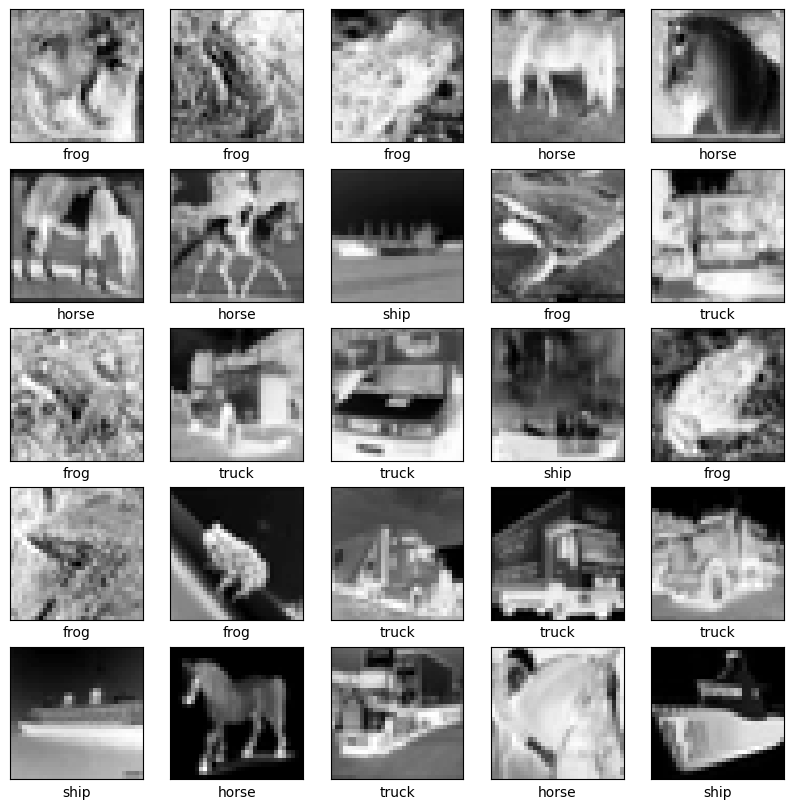

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("Versión de TensorFlow:", tf.__version__)


# =========================
# Carga del dataset
# =========================

# Tienes más datasets en:
# https://www.tensorflow.org/api_docs/python/tf/keras/datasets

# datasetKeras = tf.keras.datasets.fashion_mnist
datasetKeras = tf.keras.datasets.cifar10

(train_images, train_labels), (test_images, test_labels) = datasetKeras.load_data()


# =========================
# Nombres de las clases
# =========================

class_names_fashion = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

class_names_cifar10 = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

# Seleccionar los nombres de clase correspondientes al dataset utilizado
class_names = class_names_cifar10


# =========================
# Reducción opcional del número de clases
# =========================

# Si se desea limitar el número de clases, se puede usar una función
# auxiliar como esta:
# class_names, train_images, train_labels, test_images, test_labels = reducirNumeroClases(
#     class_names, train_images, train_labels, test_images, test_labels
# )


# =========================
# Crear conjunto de validación
# =========================

# Separar una partición de validación a partir del conjunto de entrenamiento
rate_val = 0.2

val_images = train_images[:int(len(train_images) * rate_val)]
val_labels = train_labels[:int(len(train_labels) * rate_val)]

train_images = train_images[int(len(train_images) * rate_val):]
train_labels = train_labels[int(len(train_labels) * rate_val):]

# Aplanar las etiquetas para trabajar más cómodamente
train_labels = train_labels.flatten()
val_labels = val_labels.flatten()
test_labels = test_labels.flatten()


# =========================
# Conversión a escala de grises
# =========================

# Si las imágenes tienen 3 canales (RGB), convertirlas a escala de grises
if len(train_images.shape) == 4:
    train_gray = tf.image.rgb_to_grayscale(train_images)
    val_gray = tf.image.rgb_to_grayscale(val_images)
    test_gray = tf.image.rgb_to_grayscale(test_images)

    train_images = tf.squeeze(train_gray).numpy()
    val_images = tf.squeeze(val_gray).numpy()
    test_images = tf.squeeze(test_gray).numpy()


# =========================
# Normalización
# =========================

# Normalizar las imágenes para que sus valores estén entre 0 y 1
train_images = train_images / 255.0
val_images = val_images / 255.0
test_images = test_images / 255.0


# =========================
# Configuraciones de desequilibrio
# =========================

# No aplicar reducción a ninguna clase
REDUCCION_ORIGINAL = {}

# Configuración severa de desequilibrio
REDUCCION_SEVERA = {
    0: 0.999,
    1: 0.999,
    2: 0.999,
    3: 0.999,
    4: 0.999,
    5: 0.999,
    6: 0.70,
    7: 0.70,
    8: 0.70,
    9: 0.50
}

# Aplicar desequilibrio al conjunto de entrenamiento
train_images, train_labels = aplicarDesequilibrio(
    train_images,
    train_labels,
    REDUCCION_SEVERA
)


# =========================
# Información de las particiones
# =========================

print("Total train:", train_images.shape, "|", train_labels.shape)
print("Total val:  ", val_images.shape, "|", val_labels.shape)
print("Total test: ", test_images.shape, "|", test_labels.shape)

# Mostrar distribución de clases en train, validación y test
mostrarDistribucionClases(train_labels, val_labels, test_labels)


# =========================
# Visualización de ejemplos
# =========================

# Mostrar algunos ejemplos de las imágenes cargadas
muestraImagenes(train_images, train_labels, class_names, numImagenes=25)

## Redes neuronales de ejemplo

In [4]:
def createModel1(input_shape):
    """
    Crea un modelo denso sencillo para clasificación multiclase.

    Parámetros:
    - input_shape: forma de entrada de las imágenes.

    Devuelve:
    - model: modelo compilado de Keras.
    """
    # Capa de entrada
    inputs = tf.keras.layers.Input(shape=input_shape)

    # Aplanar la imagen para poder conectarla a capas densas
    x = tf.keras.layers.Flatten()(inputs)

    # Capa densa oculta
    x = tf.keras.layers.Dense(128, activation="relu")(x)

    # Capa de salida sin activación
    x = tf.keras.layers.Dense(len(class_names))(x)

    # Capa final con softmax para obtener probabilidades
    outputs = tf.keras.layers.Activation("softmax")(x)

    # Crear y compilar el modelo
    model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def createModel2(input_shape):
    """
    Crea un modelo denso más profundo con dropout.

    Parámetros:
    - input_shape: forma de entrada de las imágenes.

    Devuelve:
    - model: modelo compilado de Keras.
    """
    # Capa de entrada
    inputs = tf.keras.layers.Input(shape=input_shape)

    # Aplanar la imagen
    x = tf.keras.layers.Flatten()(inputs)

    # Capas densas con dropout
    x = tf.keras.layers.Dense(512, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)

    # Capa de salida sin activación
    x = tf.keras.layers.Dense(len(class_names))(x)

    # Capa final con softmax
    outputs = tf.keras.layers.Activation("softmax")(x)

    # Crear y compilar el modelo
    model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def createModel3(input_shape):
    """
    Crea una red convolucional sencilla para clasificación multiclase.

    Parámetros:
    - input_shape: forma de entrada de las imágenes en escala de grises,
      por ejemplo (alto, ancho).

    Devuelve:
    - model: modelo compilado de Keras.
    """
    # Capa de entrada. Se añade explícitamente el canal porque se trabaja
    # con imágenes en escala de grises
    inputs = tf.keras.layers.Input(shape=(input_shape[0], input_shape[1], 1))

    # Bloques convolucionales con max pooling y dropout
    x = tf.keras.layers.Conv2D(32, (3, 3), activation="relu")(inputs)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.Conv2D(64, (3, 3), activation="relu")(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.Conv2D(128, (3, 3), activation="relu")(x)

    # Aplanar para conectar con capas densas
    x = tf.keras.layers.Flatten()(x)

    # Capa densa final con dropout
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    # Capa de salida sin activación
    x = tf.keras.layers.Dense(len(class_names))(x)

    # Capa final con softmax
    outputs = tf.keras.layers.Activation("softmax")(x)

    # Crear y compilar el modelo
    model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## Calibración del modelo

### Funciones auxiliares relacionadas con la calibración

In [5]:
from sklearn.calibration import CalibrationDisplay, calibration_curve
from sklearn.metrics import accuracy_score, brier_score_loss

import numpy as np
import matplotlib.pyplot as plt
import math


def calculatePositionInterval(n_bins, confidence):
    """
    Calcula el índice del intervalo al que pertenece una confianza dada y
    el valor medio de dicho intervalo.

    Parámetros:
    - n_bins: número de intervalos.
    - confidence: valor de confianza.

    Devuelve:
    - idx: índice del intervalo al que pertenece la confianza.
    - mean_value: valor medio del intervalo correspondiente.
    """
    # Calcular la anchura de cada intervalo
    bin_width = 1.0 / n_bins

    # Si la confianza no es válida, devolver None
    if math.isnan(confidence):
        return None, None

    # Calcular el índice del intervalo
    idx = int(confidence // bin_width)

    # Ajustar el caso confidence == 1.0 para que caiga en el último intervalo
    if idx == n_bins:
        idx = n_bins - 1

    # Calcular el valor medio del intervalo
    mean_value = (idx + 0.5) * bin_width

    return idx, mean_value


def calculateBinMeans(n_bins):
    """
    Calcula los valores medios de todos los intervalos.

    Parámetros:
    - n_bins: número de intervalos.

    Devuelve:
    - bin_means: lista con el valor medio de cada intervalo.
    """
    # Calcular la anchura de cada intervalo
    bin_width = 1.0 / n_bins

    # Inicializar una lista para almacenar los valores medios
    bin_means = []

    # Calcular el valor medio de cada intervalo
    for i in range(n_bins):
        mean_value = (i + 0.5) * bin_width
        bin_means.append(mean_value)

    return bin_means


def generate_lists_with_intervals(list_probs_true_total, list_probs_pred_total, n_bins=10):
    """
    Genera listas agrupando probabilidades verdaderas según los intervalos
    definidos sobre las probabilidades predichas.

    Parámetros:
    - list_probs_true_total: lista o array con probabilidades verdaderas.
    - list_probs_pred_total: lista o array con probabilidades predichas.
    - n_bins: número de intervalos que se desea utilizar.

    Devuelve:
    - avg_prob_true_in_intervals: media de probabilidades verdaderas en cada intervalo.
    - prob_pred_intervals: valor medio de cada intervalo de probabilidad predicha.
    """
    # Inicializar listas para almacenar probabilidades en cada intervalo
    prob_true_in_intervals = [[] for _ in range(n_bins)]
    prob_pred_intervals = calculateBinMeans(n_bins)

    # Recorrer las probabilidades predichas y verdaderas
    for pred_prob, true_prob in zip(list_probs_pred_total, list_probs_true_total):
        idx_bin, _ = calculatePositionInterval(n_bins, pred_prob)

        if idx_bin is not None:
            prob_true_in_intervals[idx_bin].append(true_prob)

    # Calcular la media de las probabilidades verdaderas en cada intervalo
    avg_prob_true_in_intervals = [
        np.mean(interval_probs) if len(interval_probs) > 0 else np.nan
        for interval_probs in prob_true_in_intervals
    ]

    return avg_prob_true_in_intervals, prob_pred_intervals


def calibration_display_average_multiclass(
    classifiers,
    X_test,
    y_test,
    func_predict,
    params=None,
    n_bins=10,
    ax=None,
    addPerfectlyCalibrated=True
):
    """
    Visualiza en una gráfica el promedio de las confianzas obtenidas para cada
    intervalo en un problema multiclase.

    Parámetros:
    - classifiers: diccionario con los modelos a comparar y sus nombres.
    - X_test: muestras del conjunto de test.
    - y_test: etiquetas reales del conjunto de test.
    - func_predict: función que obtiene las probabilidades predichas por el modelo.
    - params: parámetros opcionales para la función de predicción.
    - n_bins: número de intervalos utilizados.
    - ax: ejes de matplotlib sobre los que representar la gráfica.
    - addPerfectlyCalibrated: indica si se añade la diagonal de calibración perfecta.

    Devuelve:
    - ax: ejes con la gráfica de calibración.
    """
    if ax is None:
        _, ax = plt.subplots()

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Accuracy")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

    # Calcular la curva de calibración para cada clasificador
    for name, clf in classifiers.items():
        list_probs_true_total = []
        list_probs_pred_total = []

        # Calcular curvas one-vs-rest para cada clase
        for i in np.unique(y_test):
            prob_true, prob_pred = calibration_curve(
                (y_test == i).astype(int),
                func_predict(clf, X_test, params)[:, i],
                n_bins=n_bins
            )
            list_probs_true_total.extend(prob_true)
            list_probs_pred_total.extend(prob_pred)

        # Agrupar los resultados por intervalos
        prob_true_avg, prob_pred_avg = generate_lists_with_intervals(
            list_probs_true_total,
            list_probs_pred_total,
            n_bins=n_bins
        )

        ax.plot(prob_pred_avg, prob_true_avg, marker="o", label=name)

    # Añadir la línea de calibración perfecta
    if addPerfectlyCalibrated:
        ax.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            color="black",
            label="Perfectly calibrated"
        )

    ax.legend(loc="lower right")

    return ax


def expected_calibration_error(classifiers, X_test, y_test, func_predict, params=None, n_bins=10):
    """
    Calcula el ECE para varios clasificadores.

    Parámetros:
    - classifiers: diccionario con los modelos a comparar y sus nombres.
    - X_test: muestras del conjunto de test.
    - y_test: etiquetas reales del conjunto de test.
    - func_predict: función que obtiene las probabilidades predichas por el modelo.
    - params: parámetros opcionales para la función de predicción.
    - n_bins: número de intervalos utilizados.

    Devuelve:
    - ece_dict: diccionario con el ECE de cada clasificador.
    """
    ece_dict = {}

    for clf_name, clf in classifiers.items():
        # Obtener las probabilidades predichas por el clasificador
        y_proba = func_predict(clf, X_test, params)

        # Calcular el ECE para el clasificador actual
        ece = calculate_ece(y_proba, y_test, n_bins)
        ece_dict[clf_name] = round(ece, 3)

    return ece_dict


def calculate_ece(y_proba, y_true, n_bins=10):
    """
    Calcula el Expected Calibration Error (ECE) a partir de las probabilidades
    predichas y las etiquetas reales.

    Parámetros:
    - y_proba: probabilidades predichas por el modelo.
    - y_true: etiquetas reales.
    - n_bins: número de intervalos utilizados.

    Devuelve:
    - ece: valor del ECE.
    """
    # Definir los límites de los intervalos
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    # Obtener confianza y clase predicha de cada ejemplo
    confidences = np.max(y_proba, axis=1)
    predicted_label = np.argmax(y_proba, axis=1)
    accuracies = predicted_label == y_true

    ece = np.zeros(1)

    # Recorrer cada intervalo
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = np.logical_and(
            confidences > bin_lower.item(),
            confidences <= bin_upper.item()
        )

        prop_in_bin = in_bin.astype(float).mean()

        if prop_in_bin.item() > 0:
            accuracy_in_bin = accuracies[in_bin].astype(float).mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

    return ece.item()

## **Entrenamiento**

### Entrenamiento de los modelos

In [ ]:
# =========================
# Creación de modelos base
# =========================

# Obtener la forma de entrada a partir de una imagen del conjunto de entrenamiento
input_shape = train_images[0].shape

# Crear dos modelos con la misma arquitectura:
# uno se entrenará sin aumento de datos y otro con aumento
modelBase_noAumentado = createModel3(input_shape)
modelBase_aumentado = createModel3(input_shape)

# Mostrar el resumen del modelo base
modelBase_noAumentado.summary()


# =========================
# Parámetros de entrenamiento
# =========================

epochs = 20
batch_size = 128

# Fijar semilla para facilitar la reproducibilidad
tf.random.set_seed(200)


# =========================
# Entrenamiento sin aumento de datos
# =========================

print("Training base model...")
history_noAumentado = modelBase_noAumentado.fit(
    train_images,
    train_labels,
    validation_data=(val_images, val_labels),
    epochs=epochs,
    batch_size=batch_size
)


# =========================
# Entrenamiento con aumento de datos
# =========================

print("Training augmented model...")
history_aumentado = entrenaConGeneradorAumentados(
    modelBase_aumentado,
    train_images,
    train_labels,
    val_images,
    val_labels,
    epochs,
    batch_size
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,234 (1.36 MB)

 Trainable params: 356,234 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Training base model...
Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 33s 559ms/step - accuracy: 0.3152 - loss: 1.5521 - val_accuracy: 0.1383 - val_loss: 3.0857
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 252ms/step - accuracy: 0.4465 - loss: 1.2832 - val_accuracy: 0.2287 - val_loss: 3.7959
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 220ms/step - accuracy: 0.5611 - loss: 1.1039 - val_accuracy: 0.2563 - val_loss: 4.7523
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 239ms/step - accuracy: 0.6196 - loss: 0.9821 - val_accuracy: 0.2633 - val_loss: 4.7935
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 251ms/step - accuracy: 0.6679 - loss: 0.8955 - val_accuracy: 0.2781 - val_loss: 5.1772
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 262ms/step - accuracy: 0.6947 - loss: 0.8210 - val_accuracy: 0.2927 - val_loss: 5.0302
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 252ms/step - accuracy: 0.7278 - loss: 0.7639 - val_accuracy: 0.3012 - val_loss: 5.1587
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 307ms/step - accuracy: 0.7404 - 

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.3281 - loss: 1.4272 - val_accuracy: 0.1360 - val_loss: 3.4291
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 314ms/step - accuracy: 0.4185 - loss: 1.3147 - val_accuracy: 0.1986 - val_loss: 3.2955
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 0.5156 - loss: 1.2818 - val_accuracy: 0.1860 - val_loss: 3.3561
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 307ms/step - accuracy: 0.5077 - loss: 1.1830 - val_accuracy: 0.2069 - val_loss: 4.0334
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.5234 - loss: 1.2125 - val_accuracy: 0.2205 - val_loss: 4.0383
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 298ms/step - accuracy: 0.5547 - loss: 1.0920 - val_accuracy: 0.2492 - val_loss: 4.5172
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.6172 - loss: 0.9374 - val_accuracy: 0.2532 - val_loss: 4.5476
Epoch 9/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 305ms/step - accuracy: 0.6057 - loss: 0.9972 - val_accuracy: 0.2349 - v

### Inferencia

In [10]:
def predict(clf, X_test, params=None):
    """
    Obtiene las probabilidades predichas por un modelo.

    Parámetros:
    - clf: clasificador o modelo entrenado.
    - X_test: conjunto de datos sobre el que se quiere predecir.
    - params: parámetros adicionales opcionales. En esta implementación no se utilizan.

    Devuelve:
    - y_proba: probabilidades predichas por el modelo.
    """
    return clf.predict(X_test)


# =========================
# Clasificadores a evaluar
# =========================

# Diccionario con los modelos que se desean comparar
classifiersNormal = {
    "Sin aumentado": modelBase_noAumentado,
    "Con aumentado": modelBase_aumentado
}


# =========================
# Visualización de calibración
# =========================

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

n_bins = 10

calibration_display_average_multiclass(
    classifiersNormal,
    test_images,
    test_labels,
    predict,
    params=None,
    n_bins=n_bins,
    ax=ax,
    addPerfectlyCalibrated=True
)

plt.show()


# =========================
# Cálculo de métricas de calibración
# =========================

ece_base = expected_calibration_error(
    classifiersNormal,
    test_images,
    test_labels,
    predict,
    params=None,
    n_bins=n_bins
)

print("*" * 50)
print("Métricas de calibración")
print("ECE base =", ece_base)

#Implementación del alumno

En este apartado implementarás tus experimentos. Puedes basarte en el código proporcionado por el profesor. Puedes utilizar las funciones que ya hay implementadas o crearte propias en base a ese código.

Vamos a comenzar creando una función que cargue los datos desde 0 y los prepare para cada escenario.

In [11]:
import copy

# Función para obtener datos limpios según el escenario
def obtener_datos_escenario(dict_reduccion):
    """Carga y prepara los datos desde cero para evitar solapamientos."""
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

    # Partición de validación (20%)
    rate_val = 0.2
    limite = int(len(x_train) * rate_val)
    x_val, y_val = x_train[:limite], y_train[:limite]
    x_train, y_train = x_train[limite:], y_train[limite:]

    # Aplanar etiquetas
    y_train, y_val = y_train.flatten(), y_val.flatten()

    # Escala de grises y normalización
    x_train = tf.squeeze(tf.image.rgb_to_grayscale(x_train)).numpy() / 255.0
    x_val = tf.squeeze(tf.image.rgb_to_grayscale(x_val)).numpy() / 255.0

    # Aplicar desequilibrio
    x_train_desc, y_train_desc = aplicarDesequilibrio(x_train, y_train, dict_reduccion)
    return x_train_desc, y_train_desc, x_val, y_val

Entrenando escenario: Original
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 196ms/step - accuracy: 0.2689 - loss: 1.9754 - val_accuracy: 0.4149 - val_loss: 1.6404
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 202ms/step - accuracy: 0.4083 - loss: 1.6521 - val_accuracy: 0.4938 - val_loss: 1.4500
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 209ms/step - accuracy: 0.4674 - loss: 1.5088 - val_accuracy: 0.5443 - val_loss: 1.3098
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 188ms/step - accuracy: 0.5102 - loss: 1.4035 - val_accuracy: 0.5471 - val_loss: 1.2833
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 195ms/step - accuracy: 0.5364 - loss: 1.3252 - val_accuracy: 0.5904 - val_loss: 1.1903
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 188ms/step - accuracy: 0.5596 - loss: 1.2622 - val_accuracy: 0.5967 - val_loss: 1.1531
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 189ms/step - accuracy: 0.5823 - loss: 1.2046 - val_accuracy: 0.6081 - val_loss: 1.1363
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 193ms/st

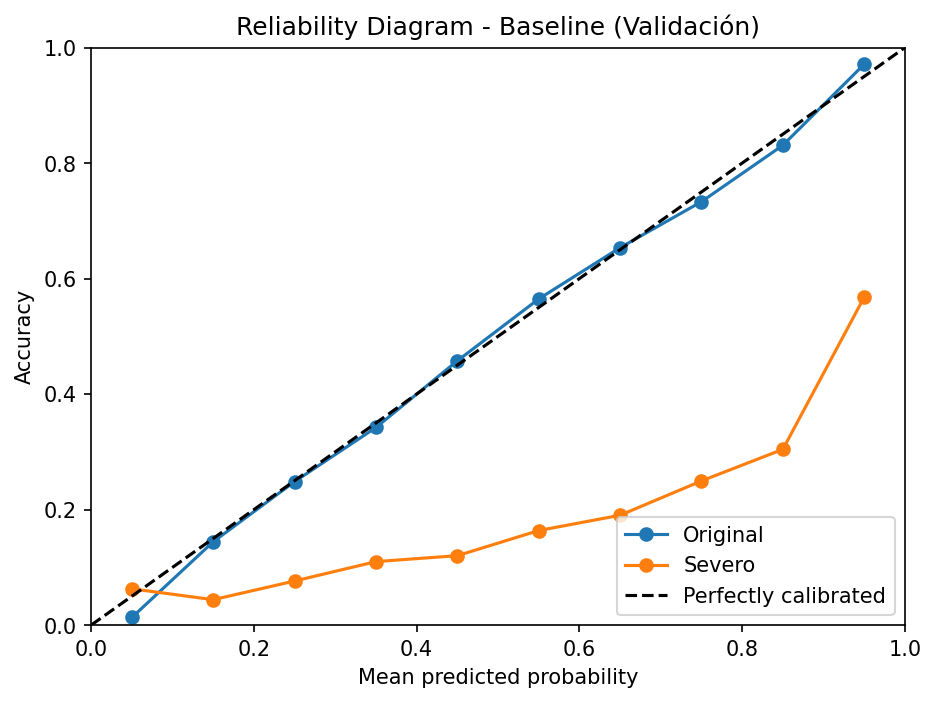

In [13]:
# BASELINE (Sin aumento de datos)

# Definición de los dos escenarios del código base
escenarios = {
    "Original": REDUCCION_ORIGINAL, # {}
    "Severo": REDUCCION_SEVERA      # {0: 0.999, ... 9: 0.50}
}

# Diccionario para guardar los modelos entrenados
modelos_base = {}

epochs = 20
batch_size = 128

# Bucle de experimentación
for nombre_escenario, dict_red in escenarios.items():
    print(f"Entrenando escenario: {nombre_escenario}")

    # Cargar datos específicos para este escenario
    x_train_actual, y_train_actual, x_val, y_val = obtener_datos_escenario(dict_red)

    # Crear modelo nuevo
    input_shape = x_train_actual[0].shape
    tf.random.set_seed(200)
    modelo = createModel3(input_shape)

    # Entrenar (sin aumento)
    modelo.fit(
        x_train_actual, y_train_actual,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    modelos_base[nombre_escenario] = modelo

# Evaluación en validación
print("Métricas de calibración en validación (Baseline)")

# Calcular Accuracy manual para validación
for nombre, modelo in modelos_base.items():
    _, acc = modelo.evaluate(x_val, y_val, verbose=0)
    print(f"Accuracy {nombre}: {acc:.4f}")

# Calcular ECE
ece_resultados = expected_calibration_error(
    modelos_base,
    x_val,
    y_val,
    predict,
    n_bins=10
)
print(f"ECE: {ece_resultados}")

# Plot
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
calibration_display_average_multiclass(
    modelos_base, x_val, y_val, predict, n_bins=10, ax=ax
)
ax.set_title("Reliability Diagram - Baseline (Validación)")
plt.show()


Estudio 1 - Escenario: Original

Entrenando con aumento suave...
Epoch 1/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 72s 223ms/step - accuracy: 0.2524 - loss: 2.0231 - val_accuracy: 0.3715 - val_loss: 1.7321
Epoch 2/20
  1/312 ━━━━━━━━━━━━━━━━━━━━ 48s 156ms/step - accuracy: 0.3594 - loss: 1.8355

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


312/312 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.3594 - loss: 1.8355 - val_accuracy: 0.3880 - val_loss: 1.7022
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 71s 220ms/step - accuracy: 0.3816 - loss: 1.7055 - val_accuracy: 0.4688 - val_loss: 1.4901
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4375 - loss: 1.5526 - val_accuracy: 0.4645 - val_loss: 1.4979
Epoch 5/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 76s 220ms/step - accuracy: 0.4411 - loss: 1.5667 - val_accuracy: 0.5133 - val_loss: 1.3707
Epoch 6/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4453 - loss: 1.5658 - val_accuracy: 0.5212 - val_loss: 1.3571
Epoch 7/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 77s 220ms/step - accuracy: 0.4824 - loss: 1.4677 - val_accuracy: 0.5539 - val_loss: 1.2702
Epoch 8/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5000 - loss: 1.4992 - val_accuracy: 0.5442 - val_loss: 1.2907
Epoch 9/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 69s 220ms/step - accuracy: 0.5104 - loss: 1.3931 - val_accura

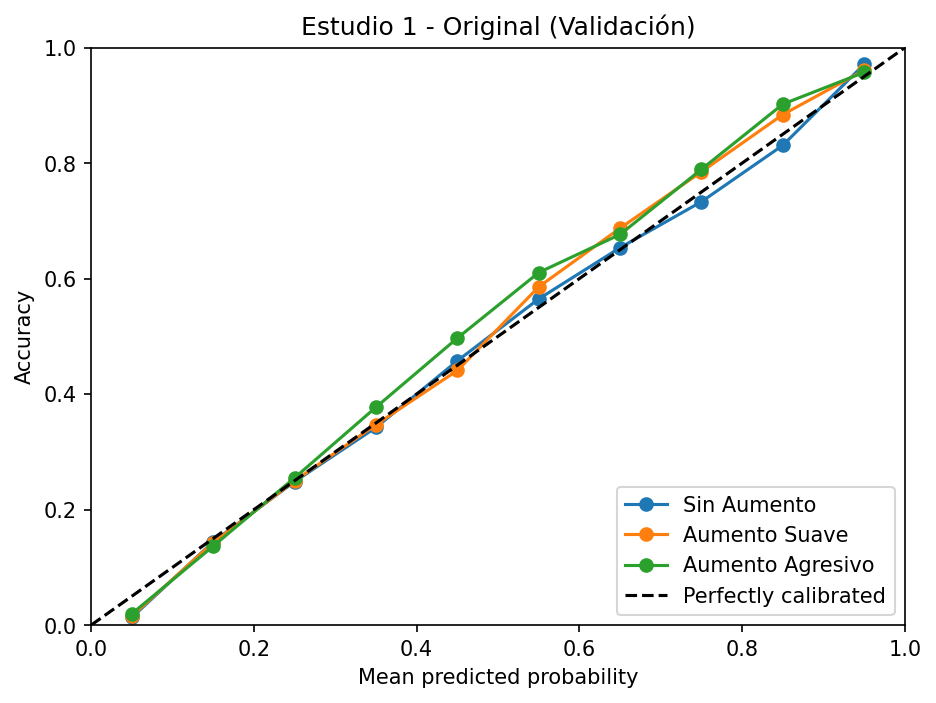

Estudio 1 - Escenario: Severo

Entrenando con aumento suave...
Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 438ms/step - accuracy: 0.3231 - loss: 1.6077 - val_accuracy: 0.1185 - val_loss: 3.2630
Epoch 2/20
 1/43 ━━━━━━━━━━━━━━━━━━━━ 8s 192ms/step - accuracy: 0.4219 - loss: 1.4177

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.4219 - loss: 1.4177 - val_accuracy: 0.1219 - val_loss: 3.2353
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 32s 316ms/step - accuracy: 0.4145 - loss: 1.3403 - val_accuracy: 0.2085 - val_loss: 3.5583
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.5156 - loss: 1.3036 - val_accuracy: 0.2058 - val_loss: 3.5166
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 319ms/step - accuracy: 0.5312 - loss: 1.1583 - val_accuracy: 0.2387 - val_loss: 3.6136
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.6406 - loss: 1.0203 - val_accuracy: 0.2421 - val_loss: 3.6426
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 310ms/step - accuracy: 0.5844 - loss: 1.0606 - val_accuracy: 0.2576 - val_loss: 3.8790
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.6484 - loss: 0.9885 - val_accuracy: 0.2629 - val_loss: 3.8740
Epoch 9/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 315ms/step - accuracy: 0.6279 - loss: 0.9685 - val_accuracy: 0.2765 - va

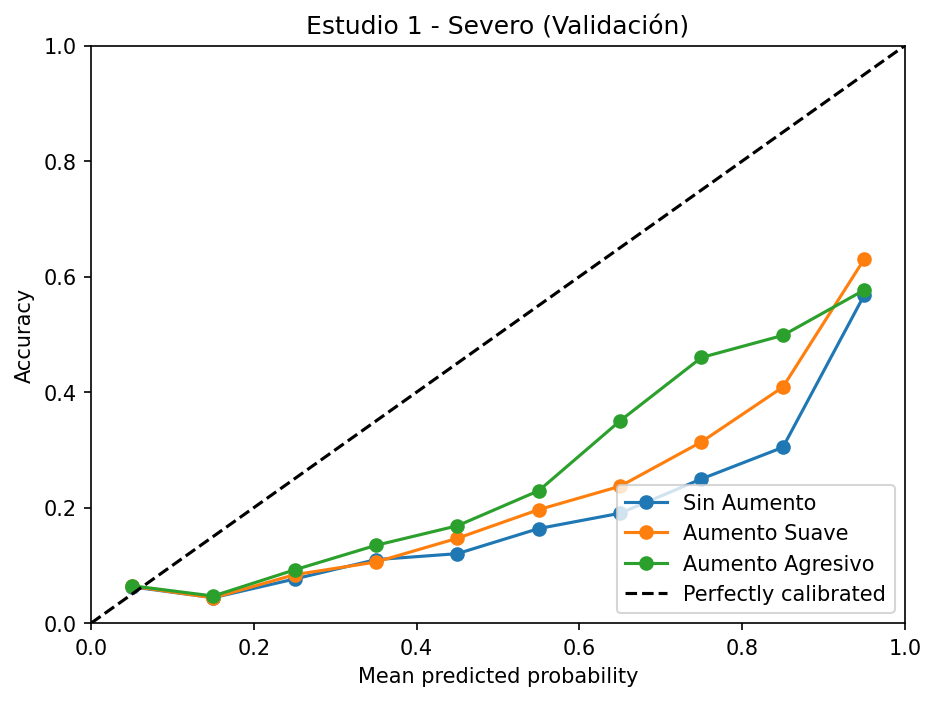

In [14]:
# ESTUDIO 1: AUMENTO DE DATOS

# Configuración 1: Aumento Suave (solo rotaciones leves y volteo)
datagen_suave = creaGeneradorAumentados(
    rotation=10,
    width_shift_range=0.0,
    height_shift_range=0.0,
    shear_range=0.0,
    zoom_range=0.0,
    horizontal_flip=True
)

# Configuración 2: Aumento Agresivo (mucha distorsión espacial)
datagen_agresivo = creaGeneradorAumentados(
    rotation=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Diccionario para guardar todos los modelos entrenados en este estudio
# Estructura: {"Escenario": {"Modelo": objeto_modelo}}
modelos_estudio1 = {
    "Original": {},
    "Severo": {}
}

# Bucle de experimentación (Escenarios x Aumentos)
for nombre_escenario, dict_red in escenarios.items():
    print(f"Estudio 1 - Escenario: {nombre_escenario}")

    # Obtener datos limpios
    x_train_actual, y_train_actual, x_val, y_val = obtener_datos_escenario(dict_red)

    # Recuperamos el modelo Base (sin aumento) de la Fase 0 para compararlo
    modelos_estudio1[nombre_escenario]["Sin Aumento"] = modelos_base[nombre_escenario]

    # ENTRENAMIENTO: AUMENTO SUAVE
    print("\nEntrenando con aumento suave...")
    tf.random.set_seed(200)
    modelo_suave = createModel3(x_train_actual[0].shape)
    entrenaConGeneradorAumentados(
        modelo_suave, x_train_actual, y_train_actual, x_val, y_val,
        epochs=epochs, batch_size=batch_size, datagen=datagen_suave
    )
    modelos_estudio1[nombre_escenario]["Aumento Suave"] = modelo_suave

    # ENTRENAMIENTO: AUMENTO AGRESIVO
    print("\nEntrenando con aumento agresivo...")
    tf.random.set_seed(200)
    modelo_agresivo = createModel3(x_train_actual[0].shape)
    entrenaConGeneradorAumentados(
        modelo_agresivo, x_train_actual, y_train_actual, x_val, y_val,
        epochs=epochs, batch_size=batch_size, datagen=datagen_agresivo
    )
    modelos_estudio1[nombre_escenario]["Aumento Agresivo"] = modelo_agresivo

    # EVALUACIÓN EN VALIDACIÓN PARA ESTE ESCENARIO
    print(f"Resultados validación ({nombre_escenario})")

    # Nos aseguramos de que x_val tenga el canal explícito (32, 32, 1)
    for nombre_mod, mod in modelos_estudio1[nombre_escenario].items():
        y_pred_proba = predict(mod, x_val)
        y_pred_clases = np.argmax(y_pred_proba, axis=1)
        acc = np.mean(y_pred_clases == y_val)
        print(f"Accuracy {nombre_mod}: {acc:.4f}")

    # ECE
    ece_resultados = expected_calibration_error(
        modelos_estudio1[nombre_escenario], x_val, y_val, predict, n_bins=10
    )
    print(f"ECE: {ece_resultados}")

    # Gráfica
    fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
    calibration_display_average_multiclass(
        modelos_estudio1[nombre_escenario], x_val, y_val, predict, n_bins=10, ax=ax
    )
    ax.set_title(f"Estudio 1 - {nombre_escenario} (Validación)")
    plt.show()

Estudio 2 - Escenario: Original

Entrenando con LS Suave (0.1)...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 211ms/step - accuracy: 0.2605 - loss: 2.0574 - val_accuracy: 0.4067 - val_loss: 1.8158
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 196ms/step - accuracy: 0.4190 - loss: 1.7810 - val_accuracy: 0.5085 - val_loss: 1.6058
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 198ms/step - accuracy: 0.4831 - loss: 1.6601 - val_accuracy: 0.5489 - val_loss: 1.5165
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 198ms/step - accuracy: 0.5233 - loss: 1.5827 - val_accuracy: 0.5858 - val_loss: 1.4501
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 197ms/step - accuracy: 0.5547 - loss: 1.5145 - val_accuracy: 0.5995 - val_loss: 1.4107
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 191ms/step - accuracy: 0.5828 - loss: 1.4625 - val_accuracy: 0.6136 - val_loss: 1.3786
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 195ms/step - accuracy: 0.6036 - loss: 1.4277 - val_accuracy: 0.6392 - val_loss: 1.3272
Epoch 8/20
313/31

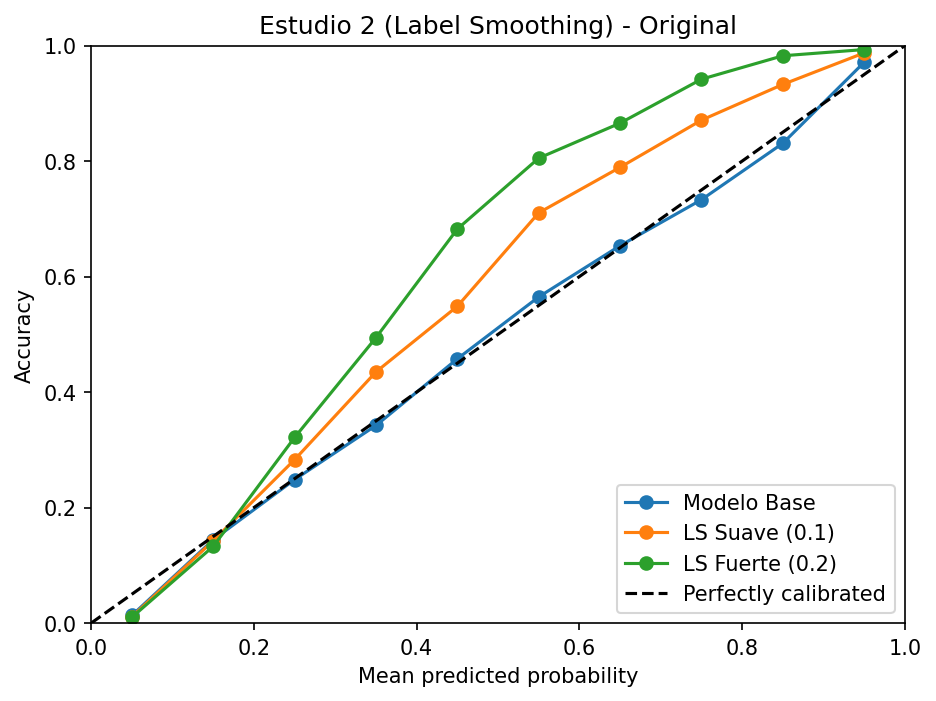

Estudio 2 - Escenario: Severo

Entrenando con LS Suave (0.1)...
Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 425ms/step - accuracy: 0.3442 - loss: 1.7105 - val_accuracy: 0.1498 - val_loss: 2.8732
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 247ms/step - accuracy: 0.4549 - loss: 1.5232 - val_accuracy: 0.2338 - val_loss: 2.8701
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 319ms/step - accuracy: 0.5602 - loss: 1.3953 - val_accuracy: 0.2544 - val_loss: 2.8791
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 274ms/step - accuracy: 0.6308 - loss: 1.2781 - val_accuracy: 0.2780 - val_loss: 2.8331
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 247ms/step - accuracy: 0.6727 - loss: 1.2157 - val_accuracy: 0.2992 - val_loss: 2.9802
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 273ms/step - accuracy: 0.7054 - loss: 1.1642 - val_accuracy: 0.3040 - val_loss: 3.1066
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 319ms/step - accuracy: 0.7442 - loss: 1.0982 - val_accuracy: 0.3160 - val_loss: 3.0210
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━

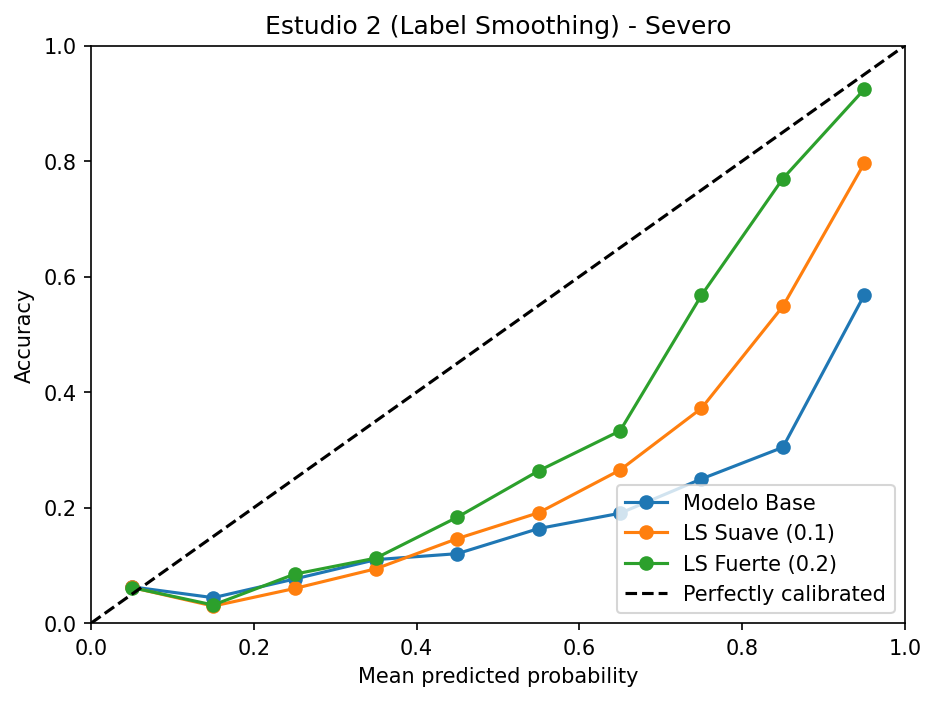

In [16]:
# ESTUDIO 2: MECANISMO ADICIONAL (LABEL SMOOTHING)

modelos_estudio2 = {
    "Original": {},
    "Severo": {}
}

# Configuraciones de Label Smoothing a probar
niveles_smoothing = {
    "LS Suave (0.1)": 0.1,
    "LS Fuerte (0.2)": 0.2
}

for nombre_escenario, dict_red in escenarios.items():
    print(f"Estudio 2 - Escenario: {nombre_escenario}")

    # Obtener datos limpios
    x_train_actual, y_train_actual, x_val, y_val = obtener_datos_escenario(dict_red)

    # Asegurar dimensiones de imagen (32, 32, 1)
    x_train_actual = np.expand_dims(x_train_actual, axis=-1) if len(x_train_actual.shape) == 3 else x_train_actual
    x_val_eval = np.expand_dims(x_val, axis=-1) if len(x_val.shape) == 3 else x_val

    # Convertir etiquetas a One-Hot
    y_train_oh = tf.keras.utils.to_categorical(y_train_actual, num_classes=10)
    y_val_oh = tf.keras.utils.to_categorical(y_val, num_classes=10)

    # Recuperamos el modelo Base de la Fase 0 para comparar
    modelos_estudio2[nombre_escenario]["Modelo Base"] = modelos_base[nombre_escenario]

    # Entrenar modelos con Label Smoothing
    for nombre_ls, valor_ls in niveles_smoothing.items():
        print(f"\nEntrenando con {nombre_ls}...")
        tf.random.set_seed(200)

        # Crear modelo
        modelo_ls = createModel3(x_train_actual[0].shape)

        # Cambiamos la función de pérdida para activar Label Smoothing
        modelo_ls.compile(
            optimizer="adam",
            loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=valor_ls),
            metrics=["accuracy"]
        )

        # Entrenar usando las etiquetas One-Hot
        modelo_ls.fit(
            x_train_actual, y_train_oh,
            validation_data=(x_val_eval, y_val_oh),
            epochs=epochs,
            batch_size=batch_size,
            verbose=1
        )

        modelos_estudio2[nombre_escenario][nombre_ls] = modelo_ls

    # EVALUACIÓN EN VALIDACIÓN
    print(f"\nResultados validación ({nombre_escenario})")

    modelos_a_evaluar = modelos_estudio2[nombre_escenario]

    # Accuracy
    for nombre_mod, mod in modelos_a_evaluar.items():
        # Usamos x_val directamente, igual que hicimos en el Estudio 1
        y_pred_proba = predict(mod, x_val)
        y_pred_clases = np.argmax(y_pred_proba, axis=1)
        acc = np.mean(y_pred_clases == y_val)
        print(f"Accuracy {nombre_mod}: {acc:.4f}")

    # ECE
    ece_resultados = expected_calibration_error(
        modelos_a_evaluar, x_val, y_val, predict, n_bins=10
    )
    print(f"ECE: {ece_resultados}")

    # Gráfica
    fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
    calibration_display_average_multiclass(
        modelos_a_evaluar, x_val, y_val, predict, n_bins=10, ax=ax
    )
    ax.set_title(f"Estudio 2 (Label Smoothing) - {nombre_escenario}")
    plt.show()

Resultados definitivos en test
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Accuracy en Test: 0.3430
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
ECE en Test: {'Mejor Modelo (LS 0.2)': 0.238}
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


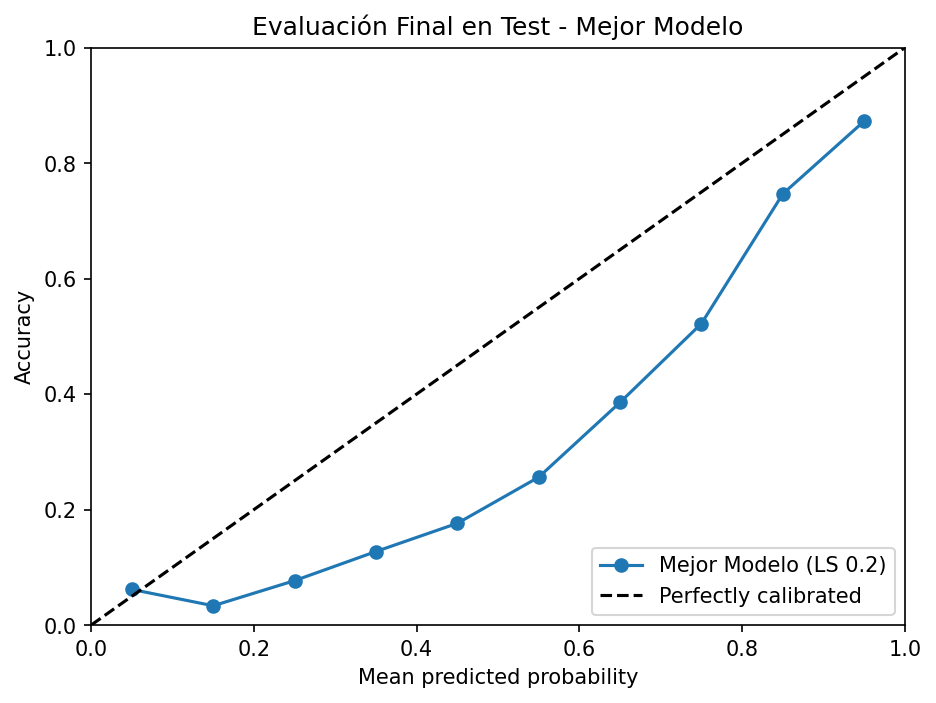

In [18]:
# EVALUACIÓN FINAL EN TEST

# Cargar y preparar el conjunto de test desde cero
(_, _), (x_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()
x_test = tf.squeeze(tf.image.rgb_to_grayscale(x_test_raw)).numpy() / 255.0
y_test = y_test_raw.flatten()

# Rescatamos el modelo ganador del Estudio 2
modelo_ganador = modelos_estudio2["Severo"]["LS Fuerte (0.2)"]
diccionario_ganador = {"Mejor Modelo (LS 0.2)": modelo_ganador}

# Evaluación
print("Resultados definitivos en test")

# Accuracy
y_pred_proba = predict(modelo_ganador, x_test)
y_pred_clases = np.argmax(y_pred_proba, axis=1)
acc_test = np.mean(y_pred_clases == y_test)
print(f"Accuracy en Test: {acc_test:.4f}")

# ECE
ece_test = expected_calibration_error(
    diccionario_ganador, x_test, y_test, predict, n_bins=10
)
print(f"ECE en Test: {ece_test}")

# Gráfica
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
calibration_display_average_multiclass(
    diccionario_ganador, x_test, y_test, predict, n_bins=10, ax=ax
)
ax.set_title("Evaluación Final en Test - Mejor Modelo")
plt.show()